# Prva kontrolna tačka: Predikcija uspešnosti mobilne aplikacije
**Studenti:** Luka Savkov (E2 63/2025), Stefan Bogdanović (R2 40/2024)  
**Predmet:** Sistemi za istraživanje i analizu podataka  
**Tema:** Regresija ocena (Rating) na osnovu metapodataka sa Google Play prodavnice.

---
### Cilj prve kontrolne tačke
Cilj ove faze je priprema podataka, eksplorativna analiza (EDA) i uspostavljanje osnovnog (baseline) modela kako bismo procenili težinu problema.

## 1. Učitavanje i priprema podataka
Koristimo skup podataka *Google Play Store Apps* sa Kaggle platforme.  
Logika za čišćenje podataka (konverzija veličina iz 'k/M/G' u MB, uklanjanje nevalidnih ocena) izdvojena je u modul `utils.py` radi preglednosti.

In [2]:
from utils import load_and_process_data

df = load_and_process_data('Google-Playstore.csv')

print(f"Broj aplikacija nakon čišćenja: {len(df)}")
df[['App Name', 'Category', 'Rating', 'Size_MB', 'Price', 'Content Rating', 'Ad Supported', 'In App Purchases']].head()

Broj aplikacija nakon čišćenja: 1230299


,App Name,Category,Rating,Size_MB,Price,Content Rating,Ad Supported,In App Purchases
1,Ampere Battery Info,Tools,4.4,2.9,0.0,Everyone,True,False
3,Smart City Trichy Public Service Vehicles 17UC...,Communication,5.0,1.8,0.0,Everyone,True,False
6,unlimited 4G data prank free app,Libraries & Demo,4.5,2.5,0.0,Everyone,True,False
7,The Everyday Calendar,Lifestyle,2.0,16.0,0.0,Everyone,False,False
9,Neon 3d Iron Tech Keyboard Theme,Personalization,4.7,3.5,0.0,Everyone,True,False


**Zapažanje:** Podaci su uspešno učitani. Uklonjene su aplikacije koje nemaju ocene (Rating Count = 0) jer one ne doprinose učenju modela.

Nakon čišćenja podataka (uklanjanje aplikacija bez ocena, parsiranje veličina i cena), analiziramo osnovne statistike skupa podataka.

In [3]:
import utils

utils.print_dataset_stats(df)

Ukupan broj aplikacija: 1230299
Broj atributa: 25
Besplatne: 1,204,765 (97.92%)
Plaćene:   25,534 (2.08%)


**Zaključak:** Dataset je značajno nebalansiran u korist besplatnih aplikacija (~98%), što je očekivano za Google Play Store, ali predstavlja izazov za modeliranje plaćenih aplikacija.

## 2. Eksplorativna analiza podataka
Analiziramo distribuciju ciljne varijable (`Rating`) kako bismo razumeli balans podataka.

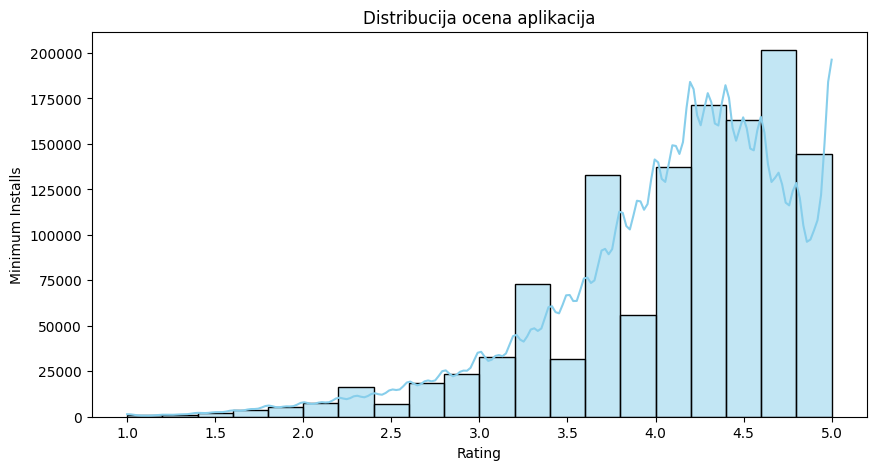

In [4]:
utils.plot_rating_distribution(df)

**Zaključak:** Distribucija je zakrivljena ulevo. Većina aplikacija ima visoke ocene (između 4.0 i 5.0), što znači da će model teže učiti da prepoznaje loše aplikacije jer ima manje primera za njih.

Proveravamo korelacije između numeričkih atributa i analiziramo kako kategorija i cena utiču na ocenu.

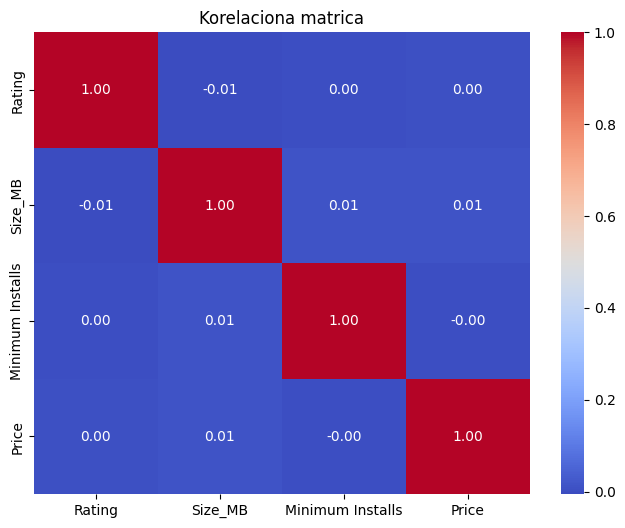

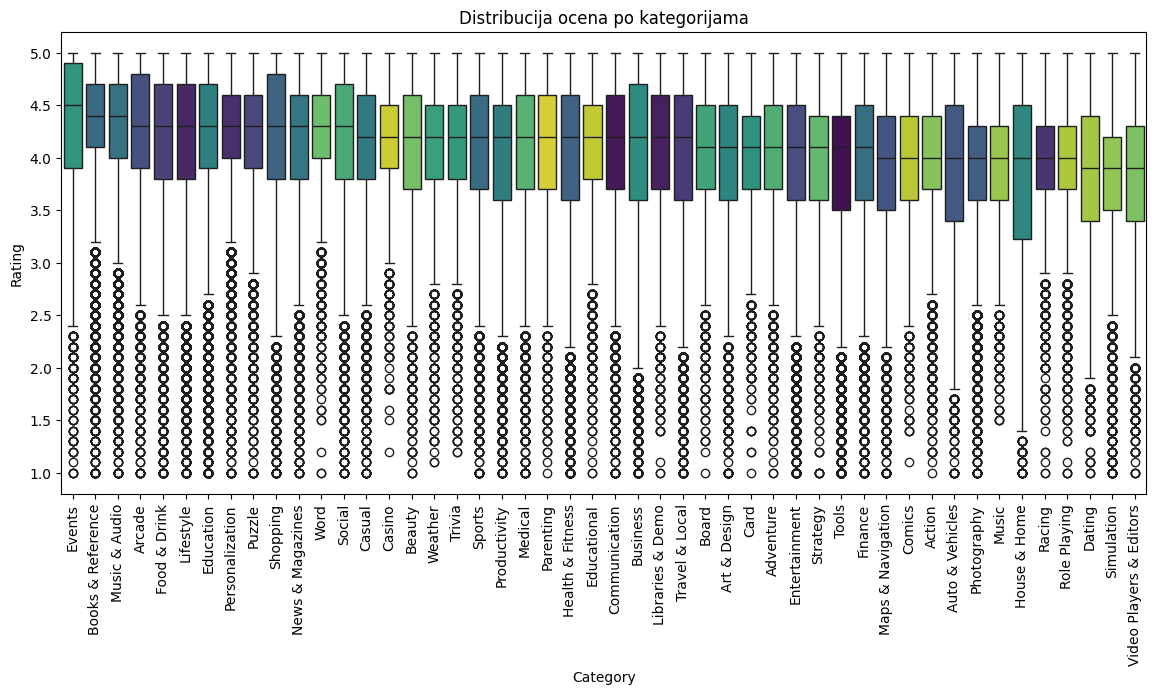

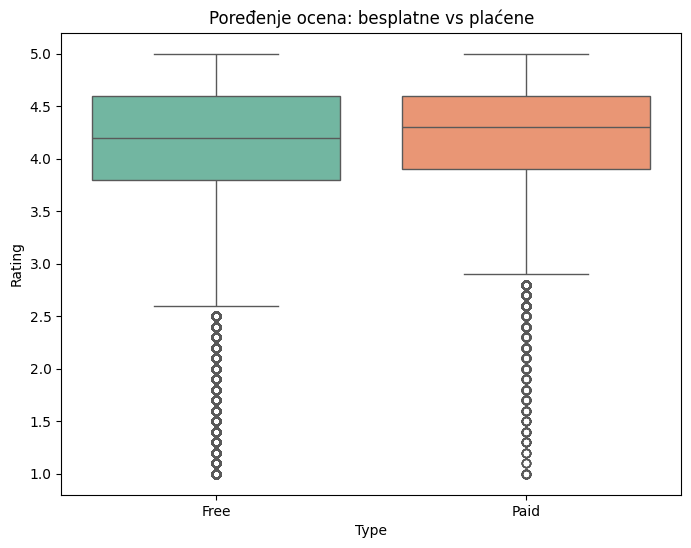

In [5]:
utils.plot_correlations(df)

utils.plot_category_impact(df)

utils.plot_price_impact(df)

**Zaključak:** Korelaciona matrica pokazuje odsustvo jake linearne veze, što sugeriše potrebu za nelinearnim modelima. Boxplotovi pokazuju da se određene kategorije (npr. Events) i plaćene aplikacije generalno bolje ocenjuju.

Pre nego što istražimo uticaj veličine na ocenu, analiziramo samu raspodelu veličina fajlova. Koristimo logaritamsku skalu jer se veličine kreću od nekoliko kilobajta do nekoliko gigabajta.

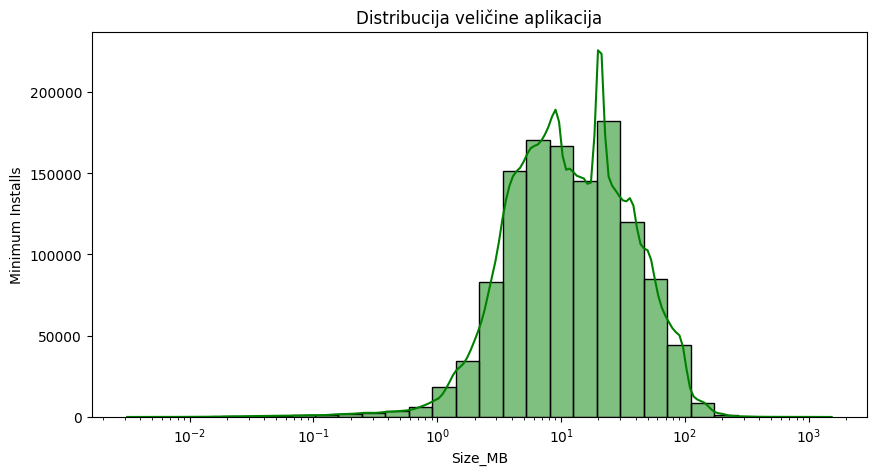

In [6]:
utils.plot_size_distribution(df)

Proveravamo da li aplikacije sa velikim brojem instalacija nužno imaju i bolje ocene? Koristimo logaritamsku skalu za broj instalacija zbog velikog raspona podataka (od 10 do 1.000.000.000+).

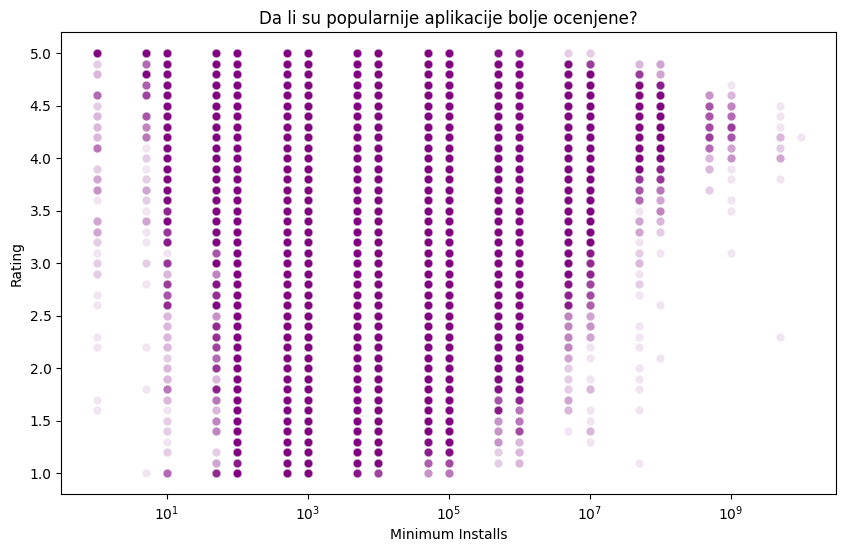

In [7]:
utils.plot_installs_vs_rating(df)

**Zaključak:**
Grafik pokazuje jasan trend stabilizacije ocena sa porastom popularnosti.
* **Male aplikacije (leva strana):** Imaju ogroman varijabilitet (ocene od 1.0 do 5.0).
* **Popularne aplikacije (desna strana):** Aplikacije sa preko 10 miliona instalacija retko imaju ocenu ispod 3.5. Ovo potvrđuje da popularnost služi kao filter kvaliteta - loše aplikacije retko postanu viralne.

Analiziramo da li uzrasno ograničenje aplikacije utiče na to kako je korisnici ocenjuju.

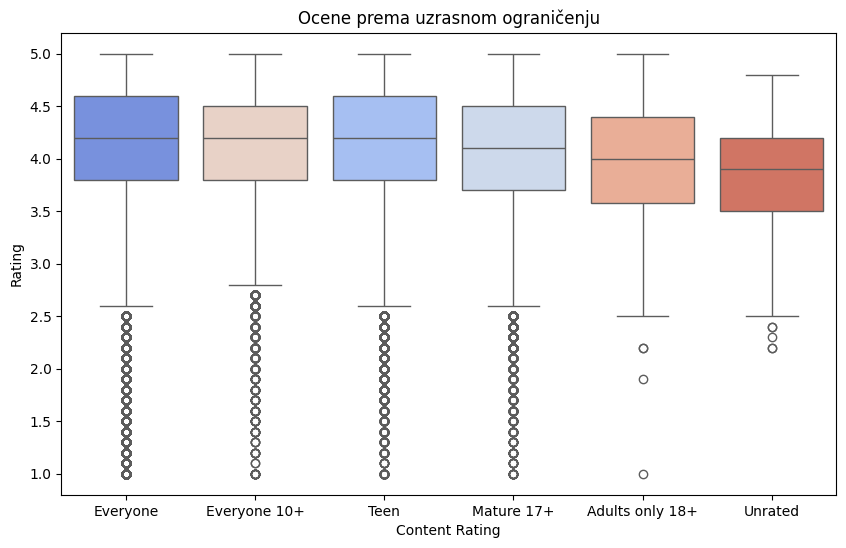

In [8]:
utils.plot_content_rating_impact(df)

## 3. Baseline Model (Random Forest)
Za prvu kontrolnu tačku koristimo **Random Forest Regressor**. Cilj je uspostaviti "baseline" rezultat (donju granicu performansi) sa kojom ćemo kasnije porediti našu neuronsku mrežu.
Podatke delimo u odnosu 80:20.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

features = ['Category', 'Size_MB', 'Minimum Installs', 'Price', 'Content Rating', 'Ad Supported', 'In App Purchases']
X = df[features].copy()
y = df['Rating']

X['Category'] = LabelEncoder().fit_transform(X['Category'].astype(str))
X['Content Rating'] = LabelEncoder().fit_transform(X['Content Rating'].astype(str))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Rezultati na test skupu:")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}") 
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

Rezultati na test skupu:
MAE: 0.4930
RMSE: 0.6619
R2 Score: 0.0783


Da bismo razumeli šta model gleda, prikazujemo važnost atributa.

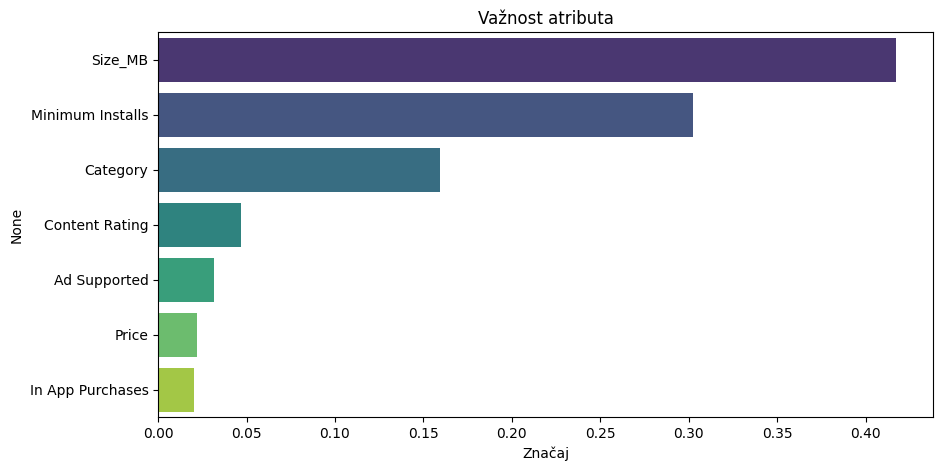

In [10]:
utils.plot_feature_importance(rf_model, features)

**Problem:** Na prethodnom grafiku vidimo da atribut `Size_MB` dominira po važnosti. Ovo budi sumnju na pojavu gde *Random Forest* algoritam veštački favorizuje atribute sa velikim brojem unikatnih numeričkih vrednosti (kao što je tačna veličina u megabajtima), čak i kada one nemaju realan uticaj na predikciju.

**Rešenje:** Da bismo dobili realniju sliku, izvršićemo **diskretizaciju** veličine aplikacije u 5 kategorija (Veoma mala, Mala, Srednja, Velika, Ogromna). Ovim sprečavamo model da "uči napamet" specifične veličine fajlova i primoravamo ga da traži generalne obrasce.

Rezultati na test skupu (SA GRUPISANOM VELIČINOM):
MAE: 0.4733
RMSE: 0.6319
R2 Score: 0.1600


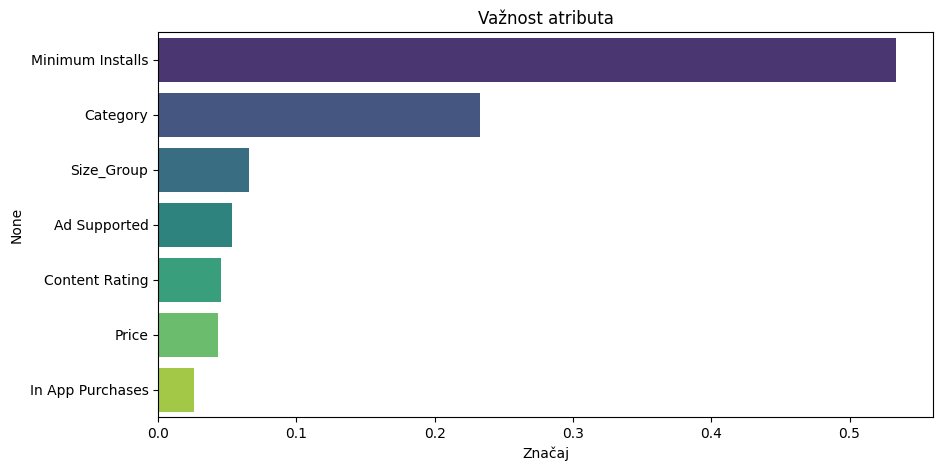

In [11]:
bins = [0, 10, 30, 60, 150, 99999]
labels = ['Veoma mala', 'Mala', 'Srednja', 'Velika', 'Ogromna']

df['Size_Group'] = pd.cut(df['Size_MB'], bins=bins, labels=labels)

features = ['Category', 'Size_Group', 'Minimum Installs', 'Price', 'Content Rating', 'Ad Supported', 'In App Purchases']
X = df[features].copy()
y = df['Rating']

label_enc = LabelEncoder()
X['Category'] = label_enc.fit_transform(X['Category'].astype(str))
X['Content Rating'] = label_enc.fit_transform(X['Content Rating'].astype(str))
X['Size_Group'] = label_enc.fit_transform(X['Size_Group'].astype(str))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
print("Rezultati na test skupu (SA GRUPISANOM VELIČINOM):")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {rmse:.4f}") 
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

utils.plot_feature_importance(rf_model, features)

**Zaključak eksperimenta:**
Nakon grupisanja veličine, struktura važnosti atributa se drastično promenila i postala logičnija:
1.  **Broj instalacija (`Minimum Installs`)** i **Kategorija** su izbili na vrh. Ovo potvrđuje da su popularnost i tip aplikacije zapravo najvažniji indikatori kvaliteta.
2.  **Veličina (`Size_Group`)** je pala na listi, što dokazuje da je njen prethodni uticaj bio delom posledica statističkog šuma.
3.  **Performanse:** Model je blago poboljšao tačnost predikcije, a sada je robusniji i manje sklon preprilagođavanju (overfitting) na specifične veličine fajlova.

## 4. Zaključak i naredni koraci
1. **Rezultat:** Dobili smo MAE od približno **0.47**. To znači da naš osnovni model promašuje ocenu aplikacije za prosečno pola zvezdice.
2. **Težina problema:** Nizak R2 score (~0.16) potvrđuje hipotezu da veza između metapodataka i ocene nije trivijalna.
3. **Plan za dalje:** U narednoj fazi planiramo implementaciju sopstvene arhitekture Veštačke neuronske mreže (ANN) kako bismo pokušali da uhvatimo nelinearne obrasce koje Random Forest nije uspeo da iskoristi.